# De Novo Peptide Sequencing Database Explorer

This notebook inspects the contents of `denovo.db` and creates visualizations of the relationships between authors, algorithms, publications, and affiliations in the field of de novo peptide sequencing.

In [207]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import networkx as nx
from collections import Counter

sns.set_theme(style="whitegrid", palette="muted")
conn = sqlite3.connect("denovo.db")

## 1. Database Overview

In [208]:
tables = ["algorithm", "publication", "author", "affiliation", "country", "city",
          "author_affiliation", "publication_author", "publication_algorithm"]

for t in tables:
    n = pd.read_sql(f"SELECT COUNT(*) as n FROM {t}", conn).iloc[0, 0]
    print(f"{t:30s} {n:>5d} rows")

algorithm                         58 rows
publication                       63 rows
author                           262 rows
affiliation                      119 rows
country                           16 rows
city                              55 rows
author_affiliation               354 rows
publication_author               421 rows
publication_algorithm             64 rows


## 2. All Algorithms

In [209]:
df_alg = pd.read_sql("SELECT name, repository FROM algorithm ORDER BY name", conn)
df_alg

,name,repository
0,AdaNovo,NaN
1,BiATNovo,NaN
2,Casanovo,https://github.com/Noble-Lab/casanovo
3,Casanovo-DB,NaN
4,Cascadia,NaN
5,ContraNovo,https://github.com/BEAM-Labs/ContraNovo
6,CrossNovo,https://github.com/BEAM-Labs/denovo
7,CycloNovo,https://github.com/bbehsaz/cyclonovo
8,DIANovo,NaN
9,DePS,NaN


## 3. Publications

In [210]:
df_pub = pd.read_sql(
    "SELECT id, title, publication_date, publication_type, doi, publisher FROM publication ORDER BY publication_date",
    conn,
    parse_dates=["publication_date"],
)
df_pub

,id,title,publication_date,publication_type,doi,publisher
0,62,De novo peptide sequencing by deep learning,2017-07-18,peer-reviewed,10.1073/pnas.1705691114,PNAS
1,61,Postnovo: Postprocessing Enables Accurate and ...,2018-10-02,peer-reviewed,10.1021/acs.jproteome.8b00278,Journal of Proteome Research
2,60,Deep learning enables de novo peptide sequenci...,2018-12-20,peer-reviewed,10.1038/s41592-018-0260-3,Nature Methods
3,59,DeepNovoV2: Better de novo peptide sequencing ...,2019-05-22,preprint,10.48550/arXiv.1904.08514,arXiv
4,58,pNovo 3: precise de novo peptide sequencing us...,2019-07-24,peer-reviewed,10.1093/bioinformatics/btz366,Bioinformatics
...,...,...,...,...,...,...
58,11,Advancing Proteomic Analyses with Graph-Based ...,2025-08-15,thesis,NaN,PhD thesis
59,10,Modanovo: A Unified Model for Post-Translation...,2025-09-16,preprint,10.1101/2025.09.12.675784,bioRxiv
60,9,Bidirectional Representations Augmented Autore...,2025-10-17,preprint,10.48550/arXiv.2510.08169,arXiv
61,8,Accurate de novo sequencing of the modified pr...,2025-12-13,preprint,10.48550/arXiv.2512.12272,arXiv


## 4. Publications Timeline

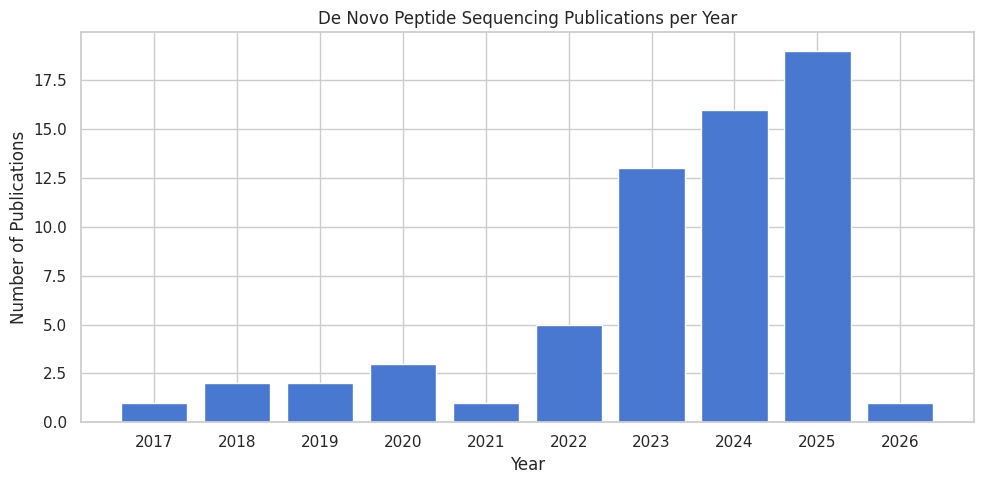

In [211]:
df_timeline = df_pub.dropna(subset=["publication_date"]).copy()
df_timeline["year"] = df_timeline["publication_date"].dt.year
year_counts = df_timeline["year"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(year_counts.index, year_counts.values, color=sns.color_palette()[0], edgecolor="white")
ax.set_xlabel("Year")
ax.set_ylabel("Number of Publications")
ax.set_title("De Novo Peptide Sequencing Publications per Year")
ax.set_xticks(year_counts.index)
plt.tight_layout()
plt.savefig("plots/publications_per_year.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Publication Types

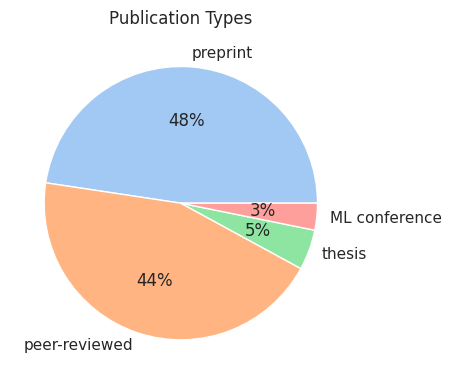

In [212]:
type_counts = df_pub["publication_type"].value_counts()
fig, ax = plt.subplots(figsize=(6, 4))
ax.pie(type_counts.values, labels=type_counts.index, autopct="%1.0f%%",
       colors=sns.color_palette("pastel"))
ax.set_title("Publication Types")
plt.tight_layout()
plt.savefig("plots/publication_types.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Top Authors by Number of Publications

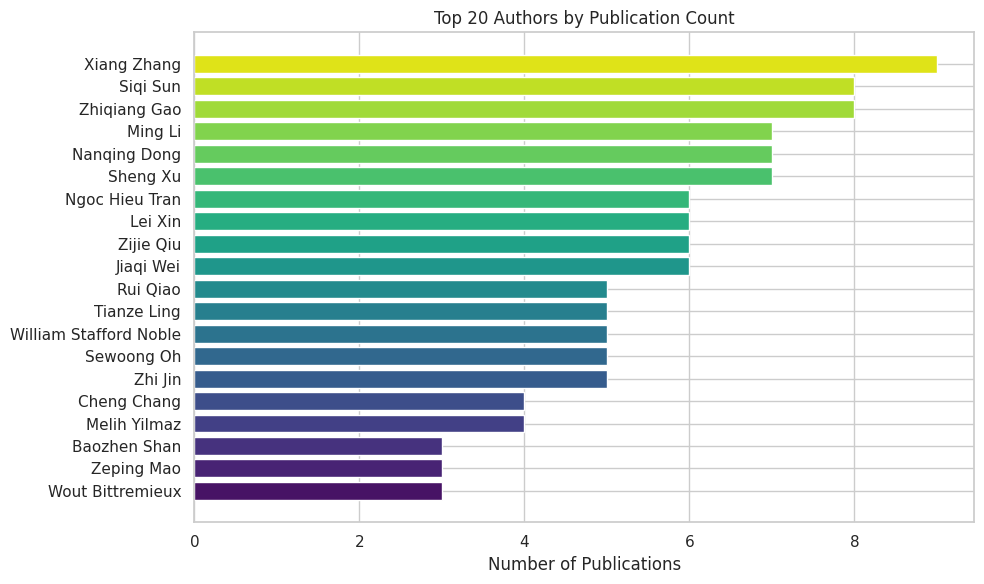

In [213]:
df_top_authors = pd.read_sql("""
    SELECT a.name, COUNT(pa.publication_id) as num_publications
    FROM author a
    JOIN publication_author pa ON a.id = pa.author_id
    GROUP BY a.id
    ORDER BY num_publications DESC
    LIMIT 20
""", conn)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(df_top_authors["name"][::-1], df_top_authors["num_publications"][::-1],
        color=sns.color_palette("viridis", len(df_top_authors)))
ax.set_xlabel("Number of Publications")
ax.set_title("Top 20 Authors by Publication Count")
plt.tight_layout()
plt.savefig("plots/top_authors.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Geographic Distribution of Affiliations

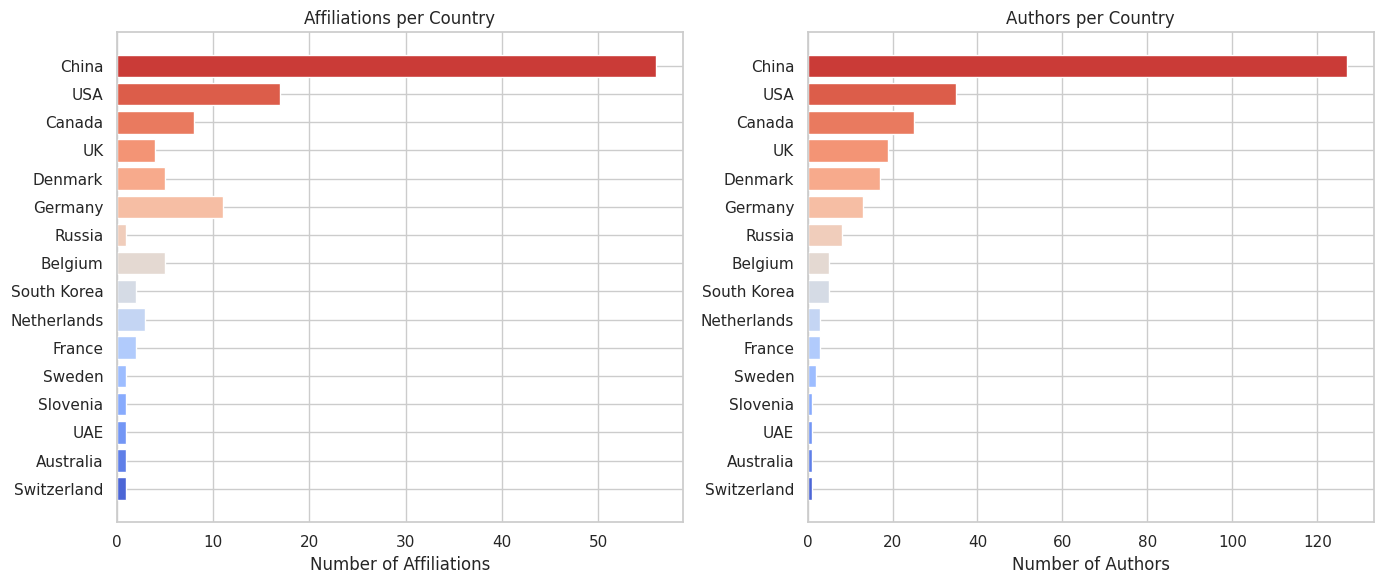

,country,num_affiliations,num_authors
0,China,56,127
1,USA,17,35
2,Canada,8,25
3,UK,4,19
4,Denmark,5,17
5,Germany,11,13
6,Russia,1,8
7,Belgium,5,5
8,South Korea,2,5
9,Netherlands,3,3


In [214]:
df_geo = pd.read_sql("""
    SELECT c.name as country, COUNT(DISTINCT af.id) as num_affiliations,
           COUNT(DISTINCT aa.author_id) as num_authors
    FROM country c
    JOIN affiliation af ON af.country_id = c.id
    LEFT JOIN author_affiliation aa ON aa.affiliation_id = af.id
    GROUP BY c.id
    ORDER BY num_authors DESC
""", conn)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(df_geo["country"][::-1], df_geo["num_affiliations"][::-1],
             color=sns.color_palette("coolwarm", len(df_geo)))
axes[0].set_xlabel("Number of Affiliations")
axes[0].set_title("Affiliations per Country")

axes[1].barh(df_geo["country"][::-1], df_geo["num_authors"][::-1],
             color=sns.color_palette("coolwarm", len(df_geo)))
axes[1].set_xlabel("Number of Authors")
axes[1].set_title("Authors per Country")

plt.tight_layout()
plt.savefig("plots/affiliations_and_authors_per_country.png", dpi=150, bbox_inches="tight")
plt.show()

df_geo

## 8. Top Institutions

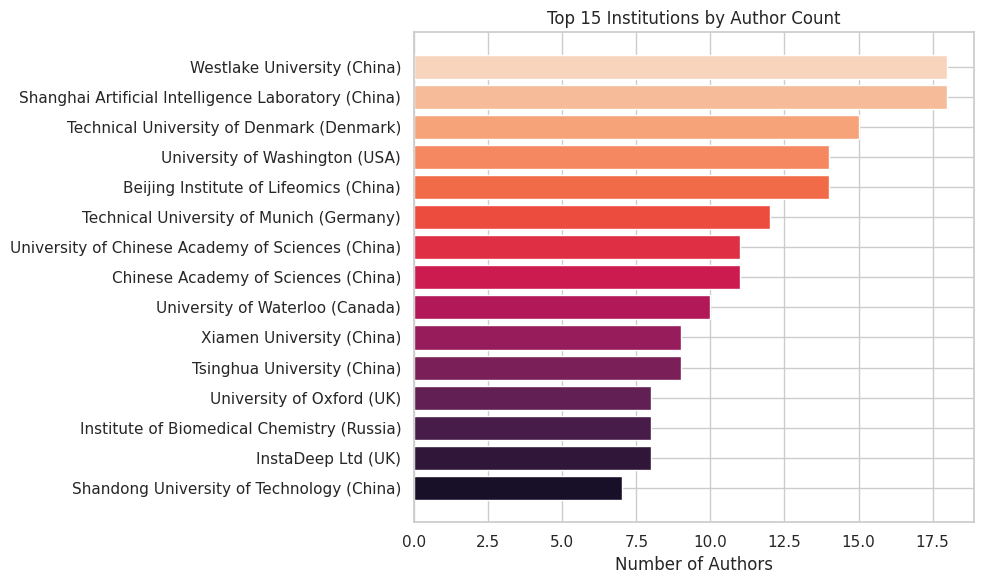

In [215]:
df_inst = pd.read_sql("""
    SELECT af.name as institution, c.name as country,
           COUNT(DISTINCT aa.author_id) as num_authors
    FROM affiliation af
    JOIN country c ON af.country_id = c.id
    JOIN author_affiliation aa ON aa.affiliation_id = af.id
    GROUP BY af.name
    ORDER BY num_authors DESC
    LIMIT 15
""", conn)

fig, ax = plt.subplots(figsize=(10, 6))
labels = [f"{r['institution']} ({r['country']})" for _, r in df_inst.iterrows()]
ax.barh(labels[::-1], df_inst["num_authors"][::-1],
        color=sns.color_palette("rocket", len(df_inst)))
ax.set_xlabel("Number of Authors")
ax.set_title("Top 15 Institutions by Author Count")
plt.tight_layout()
plt.savefig("plots/top_institutions.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Co-authorship Network

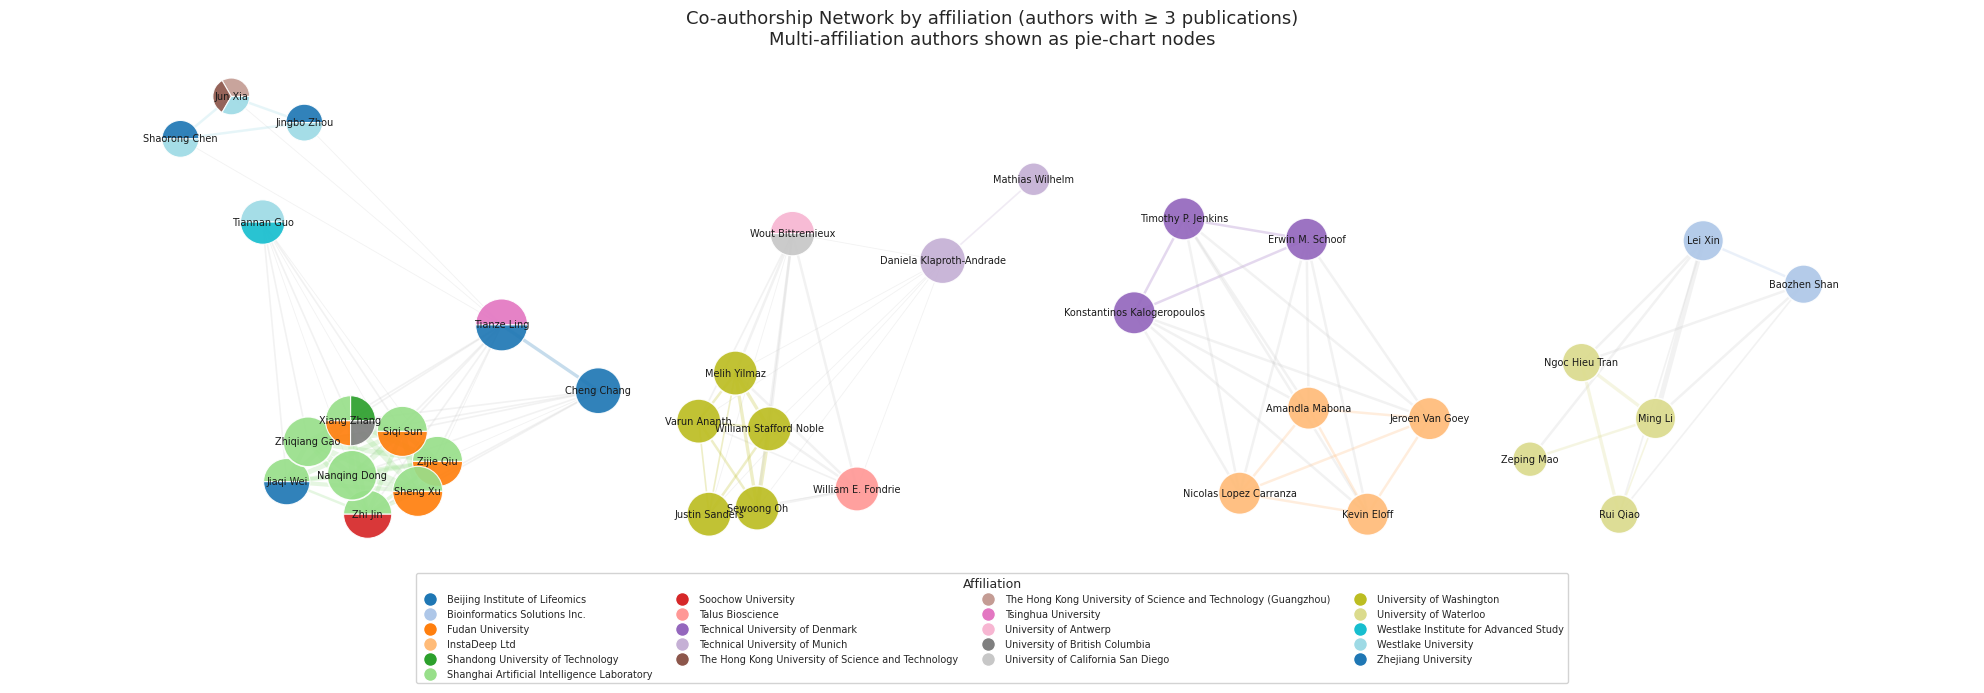

Network: 36 authors (12 with multiple affiliations), 118 co-authorship links
  Intra-affiliation edges: 57  |  Inter-affiliation edges: 61


In [216]:
from itertools import combinations
from matplotlib.lines import Line2D
from matplotlib.patches import Wedge
import numpy as np

df_coauth = pd.read_sql("""
    SELECT pa1.author_id as a1, pa2.author_id as a2, COUNT(*) as weight
    FROM publication_author pa1
    JOIN publication_author pa2 ON pa1.publication_id = pa2.publication_id
    WHERE pa1.author_id < pa2.author_id
    GROUP BY pa1.author_id, pa2.author_id
""", conn)

author_names = dict(pd.read_sql("SELECT id, name FROM author", conn).values)

G = nx.Graph()
for _, row in df_coauth.iterrows():
    n1, n2 = author_names[row["a1"]], author_names[row["a2"]]
    G.add_edge(n1, n2, weight=row["weight"])

prolific = {r[0] for r in pd.read_sql("""
    SELECT a.name FROM author a
    JOIN publication_author pa ON a.id = pa.author_id
    GROUP BY a.id HAVING COUNT(*) >= 3
""", conn).values}

G_sub = G.subgraph([n for n in G.nodes if n in prolific]).copy()

# --- Collect ALL affiliations per author ---
df_author_aff = pd.read_sql("""
    SELECT a.name as author_name, aff.name as affiliation
    FROM author a
    JOIN author_affiliation aa ON a.id = aa.author_id
    JOIN affiliation aff ON aa.affiliation_id = aff.id
    GROUP BY a.id, aff.id
""", conn)

author_all_affs = {}
for name in G_sub.nodes:
    affs = list(df_author_aff[df_author_aff["author_name"] == name]["affiliation"].unique())
    author_all_affs[name] = affs if affs else ["Unknown"]

# Primary affiliation = the one shared with most co-authors (for layout grouping)
author_primary_aff = {}
for name in G_sub.nodes:
    affs = author_all_affs[name]
    if len(affs) == 1:
        author_primary_aff[name] = affs[0]
    else:
        neighbors = list(G_sub.neighbors(name))
        best_aff, best_count = affs[0], 0
        for aff in affs:
            count = sum(1 for nb in neighbors if aff in author_all_affs.get(nb, []))
            if count > best_count:
                best_aff, best_count = aff, count
        author_primary_aff[name] = best_aff

# Colour map over all affiliations that appear
all_affs_flat = set()
for affs in author_all_affs.values():
    all_affs_flat.update(affs)
unique_affs = sorted(all_affs_flat)
palette = sns.color_palette("tab20", n_colors=len(unique_affs))
aff_color_map = dict(zip(unique_affs, palette))

# --- Layout each connected component separately, then pack together ---
components = sorted(nx.connected_components(G_sub), key=len, reverse=True)

pos = {}
GAP = 0.15
cursor_x = 0.0

for comp_nodes in components:
    comp = G_sub.subgraph(comp_nodes).copy()

    # Affiliation-aware layout within the component
    G_layout = comp.copy()
    for name in comp.nodes:
        aff = author_primary_aff[name]
        for other in comp.nodes:
            if other != name and author_primary_aff[other] == aff:
                if G_layout.has_edge(name, other):
                    G_layout[name][other]["weight"] += 8
                else:
                    G_layout.add_edge(name, other, weight=8)

    comp_pos = nx.spring_layout(G_layout, k=0.8, seed=42, iterations=200, weight="weight")

    # Normalise to unit bounding box
    xs = [p[0] for p in comp_pos.values()]
    ys = [p[1] for p in comp_pos.values()]
    x_min, x_max = min(xs), max(xs)
    y_min, y_max = min(ys), max(ys)
    x_span = max(x_max - x_min, 1e-6)
    y_span = max(y_max - y_min, 1e-6)
    scale = np.sqrt(len(comp_nodes)) / 6.0

    for name in comp_pos:
        nx_ = (comp_pos[name][0] - x_min) / x_span * scale + cursor_x
        ny_ = (comp_pos[name][1] - y_min) / y_span * scale
        pos[name] = np.array([nx_, ny_])

    cursor_x += scale + GAP

# Centre vertically
all_ys = [p[1] for p in pos.values()]
y_mid = (max(all_ys) + min(all_ys)) / 2
for name in pos:
    pos[name][1] -= y_mid

degrees = dict(G_sub.degree())
edges = list(G_sub.edges(data=True))
edge_weights = [e[2]["weight"] for e in edges]

edge_colors = []
for u, v, d in edges:
    if author_primary_aff[u] == author_primary_aff[v]:
        edge_colors.append(aff_color_map[author_primary_aff[u]])
    else:
        edge_colors.append("#cccccc")

fig, ax = plt.subplots(figsize=(20, 10))

nx.draw_networkx_edges(G_sub, pos, alpha=0.25,
                       width=[w * 0.6 for w in edge_weights],
                       edge_color=edge_colors, ax=ax)

# Draw nodes: pie-chart wedges for multi-affiliation authors
x_all = [p[0] for p in pos.values()]
x_range = max(x_all) - min(x_all)
BASE_RADIUS = x_range * 0.016

for name in G_sub.nodes:
    x, y = pos[name]
    affs = author_all_affs[name]
    r = BASE_RADIUS * (0.6 + 0.4 * degrees[name] / max(degrees.values()))
    if len(affs) == 1:
        circle = plt.Circle((x, y), r, fc=aff_color_map[affs[0]],
                             ec="white", lw=1.2, alpha=0.92, zorder=3)
        ax.add_patch(circle)
    else:
        angle_per = 360.0 / len(affs)
        for i, aff in enumerate(affs):
            wedge = Wedge((x, y), r, i * angle_per, (i + 1) * angle_per,
                          fc=aff_color_map[aff], ec="white", lw=0.8,
                          alpha=0.92, zorder=3)
            ax.add_patch(wedge)

nx.draw_networkx_labels(G_sub, pos, font_size=7, ax=ax)

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=aff_color_map[a],
           markersize=10, label=a)
    for a in unique_affs
]
ax.legend(handles=legend_elements, loc="upper center", fontsize=7,
          title="Affiliation", title_fontsize=9,
          framealpha=0.85, ncol=4,
          bbox_to_anchor=(0.5, -0.02))

ax.set_title("Co-authorship Network by affiliation (authors with ≥ 3 publications)\n"
             "Multi-affiliation authors shown as pie-chart nodes",
             fontsize=13)
ax.set_aspect("equal")
ax.axis("off")
plt.tight_layout()
plt.savefig("plots/coauthorship_network_affiliations.png", dpi=150, bbox_inches="tight")
plt.show()

multi = sum(1 for a in author_all_affs.values() if len(a) > 1)
intra = sum(1 for u, v, _ in edges if author_primary_aff[u] == author_primary_aff[v])
inter = sum(1 for u, v, _ in edges if author_primary_aff[u] != author_primary_aff[v])
print(f"Network: {G_sub.number_of_nodes()} authors ({multi} with multiple affiliations), "
      f"{G_sub.number_of_edges()} co-authorship links")
print(f"  Intra-affiliation edges: {intra}  |  Inter-affiliation edges: {inter}")

## 10. Algorithm Timeline

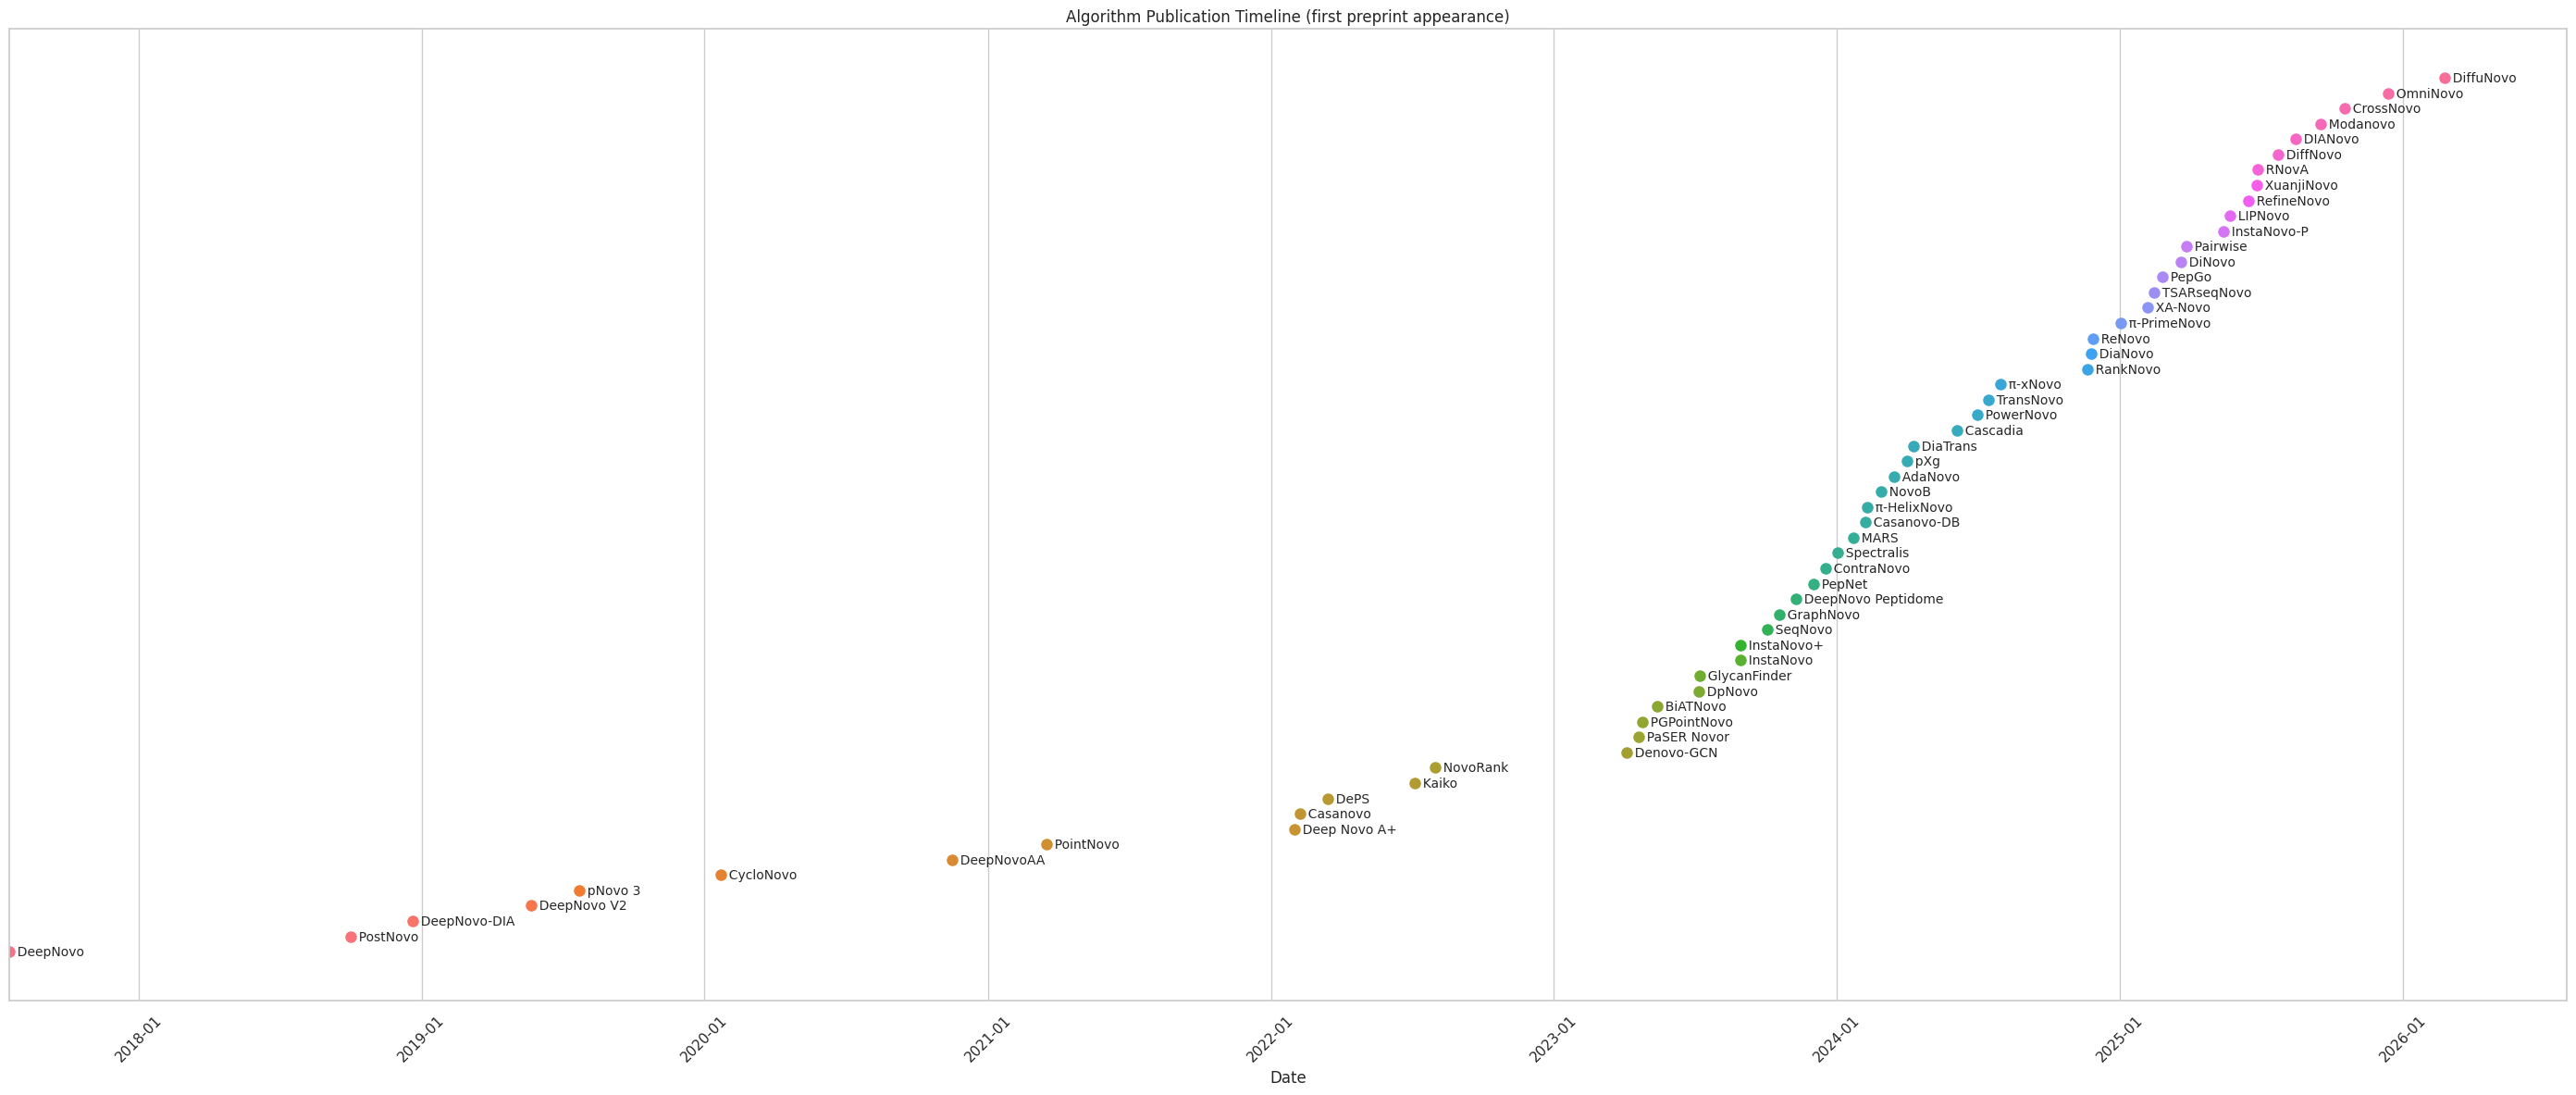

In [217]:
df_alg_timeline = pd.read_sql("""
    SELECT a.name as algorithm, MIN(p.publication_date) as first_pub
    FROM algorithm a
    JOIN publication_algorithm pa ON a.id = pa.algorithm_id
    JOIN publication p ON pa.publication_id = p.id
    WHERE p.publication_date IS NOT NULL
    GROUP BY a.id
    ORDER BY first_pub
""", conn)
df_alg_timeline["first_pub"] = pd.to_datetime(df_alg_timeline["first_pub"])

fig, ax = plt.subplots(figsize=(28, 12))
y_pos = range(len(df_alg_timeline))
colors = sns.color_palette("husl", len(df_alg_timeline))

ax.barh(y_pos, [1]*len(df_alg_timeline), left=mdates.date2num(df_alg_timeline["first_pub"]),
        height=0.6, color=colors, alpha=0)

for i, (_, row) in enumerate(df_alg_timeline.iterrows()):
    ax.plot(row["first_pub"], i, "o", color=colors[i], markersize=8)
    ax.text(row["first_pub"], i, f"  {row['algorithm']}", va="center", fontsize=10)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.set_yticks([])
ax.set_title("Algorithm Publication Timeline (first preprint appearance)")
ax.set_xlabel("Date")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("plots/publication_timeline.png", dpi=150, bbox_inches="tight")
plt.show()

## 10b. Innovations Timeline

A horizontal timeline of key innovations in deep-learning-based de novo peptide sequencing, color-coded by core architecture type.

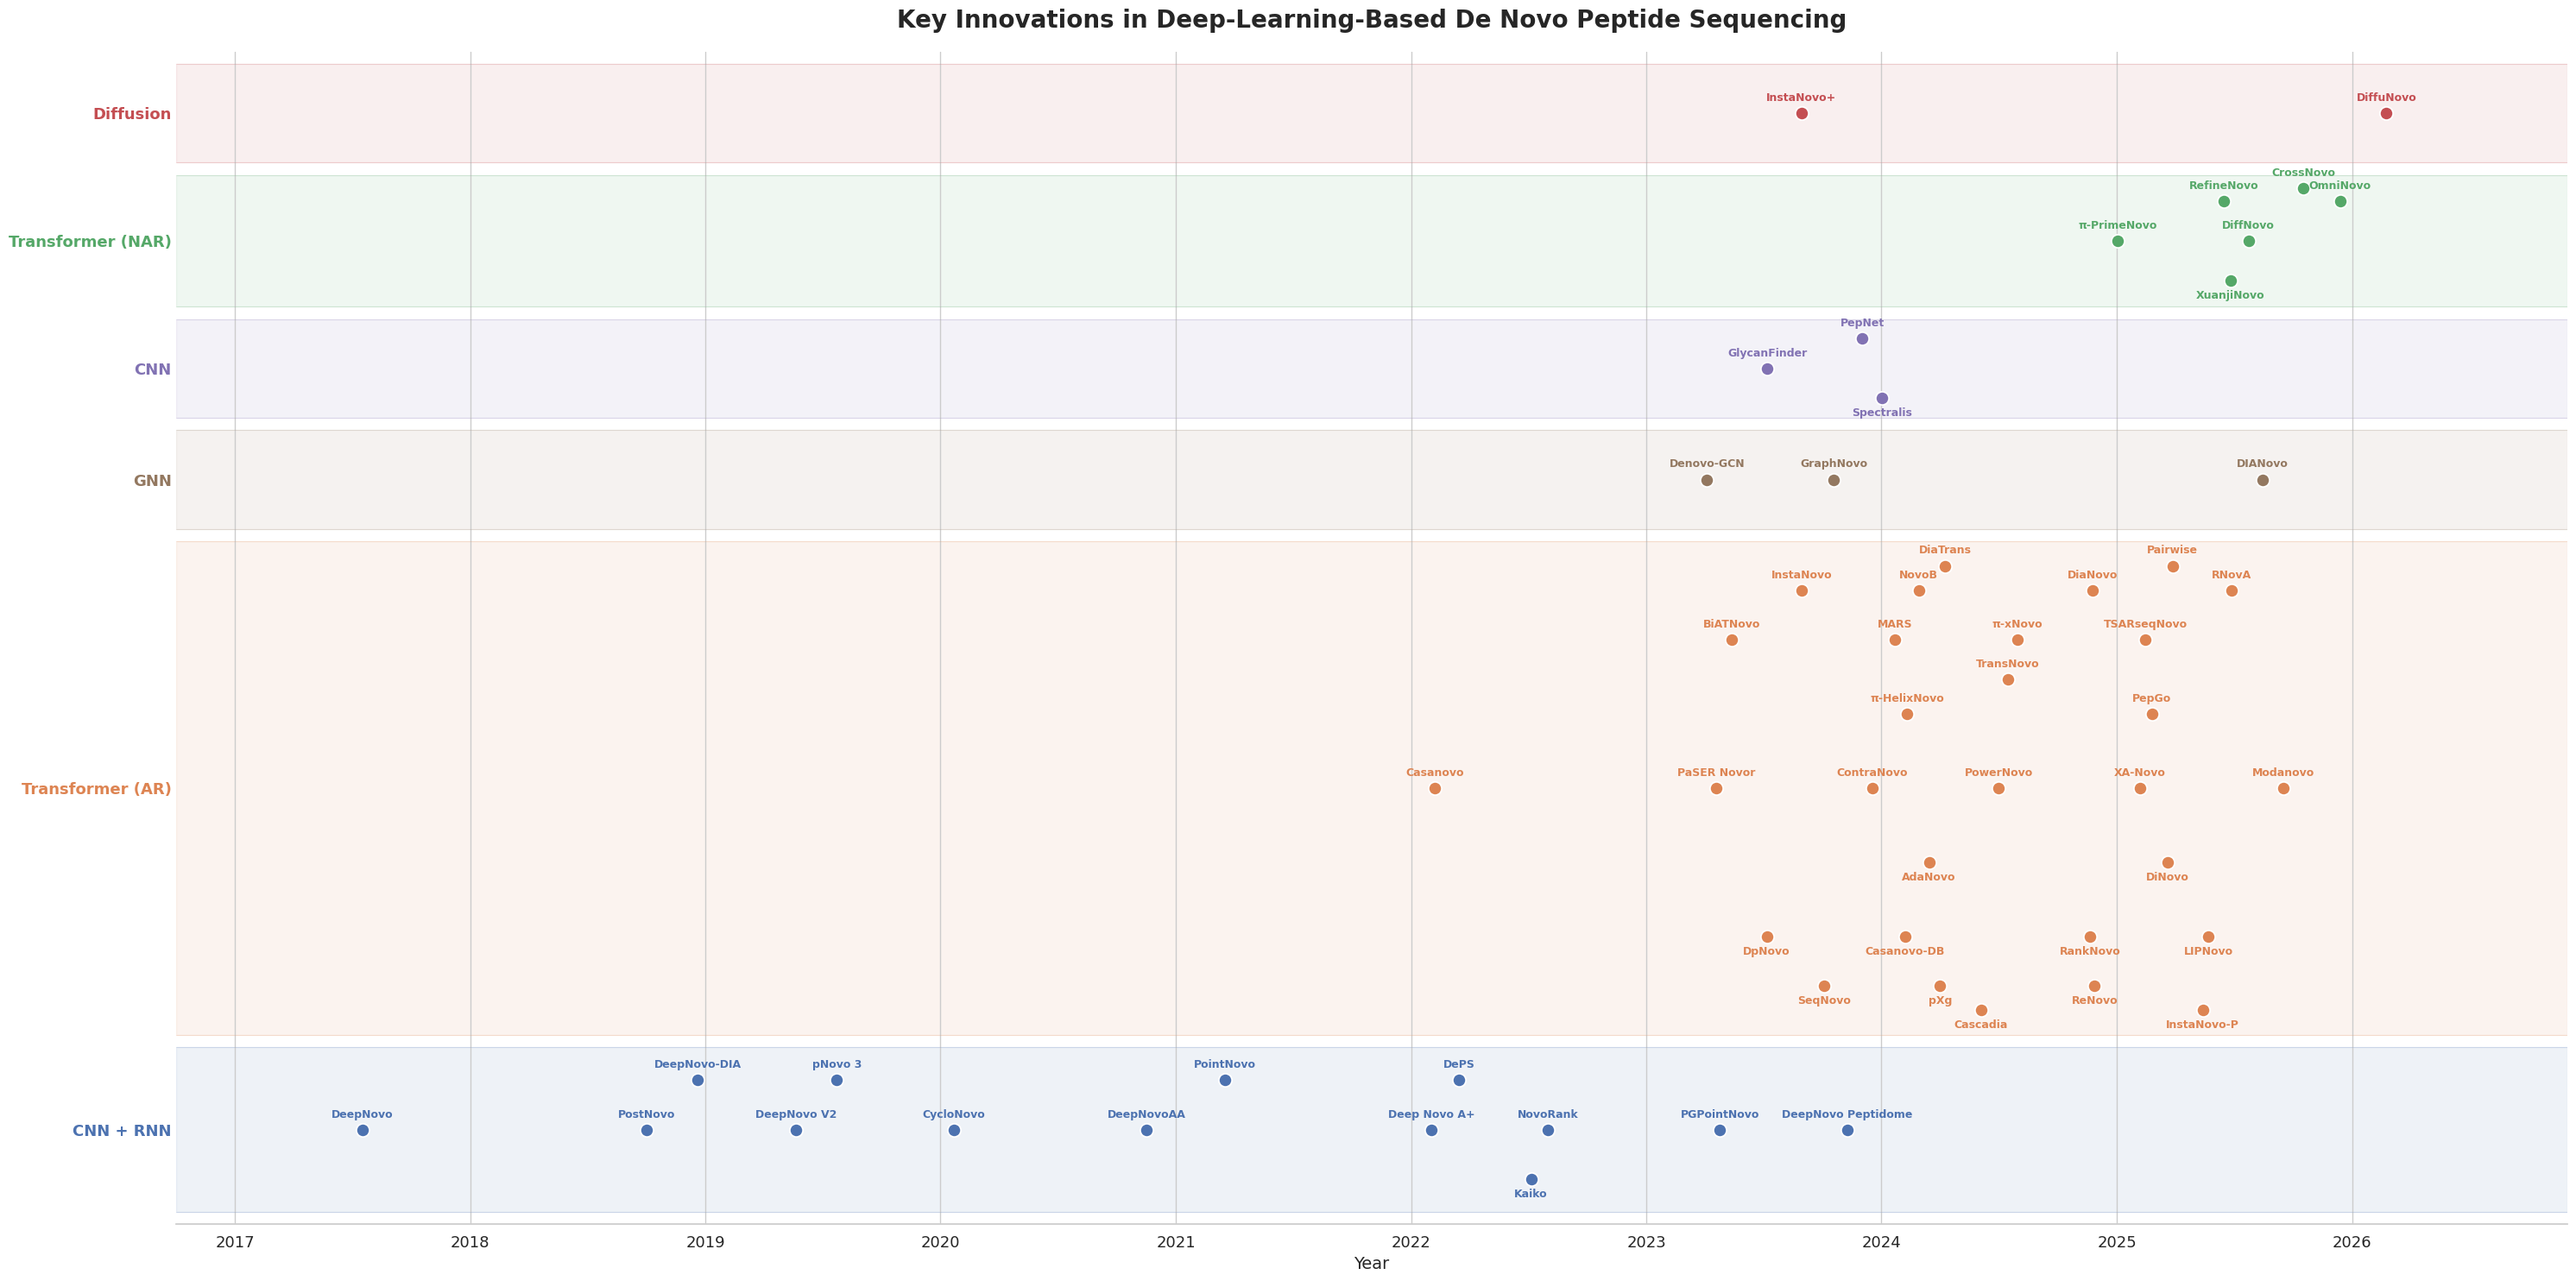

In [218]:
band_defs = [
    ("CNN + RNN",         "#4C72B0",  2.0),
    ("Transformer (AR)",  "#DD8452",  6.0),
    ("GNN",               "#937860",  1.2),
    ("CNN",               "#8172B3",  1.2),
    ("Transformer (NAR)", "#55A868",  1.6),
    ("Diffusion",         "#C44E52",  1.2),
]

BAND_GAP = 0.15

bands = {}
y_cursor = 0
for name, color, height in band_defs:
    bot = y_cursor
    top = y_cursor + height
    bands[name] = (bot, top, (bot + top) / 2, color, height)
    y_cursor = top + BAND_GAP

# Pull innovations from the database
df_innov = pd.read_sql("""
    SELECT a.name, a.algorithm_family, a.short_description,
           MIN(p.publication_date) AS first_pub
    FROM algorithm a
    JOIN publication_algorithm pa ON a.id = pa.algorithm_id
    JOIN publication p ON pa.publication_id = p.id
    WHERE a.algorithm_family IS NOT NULL
      AND p.publication_date IS NOT NULL
    GROUP BY a.id
    ORDER BY first_pub
""", conn)
df_innov["first_pub"] = pd.to_datetime(df_innov["first_pub"])

# Compute y_frac within each band to avoid label overlap.
# Items < 120 days apart in the same band cycle through tiers.
Y_TIERS = [0.5, 0.8, 0.2, 0.9, 0.1, 0.65, 0.35, 0.95, 0.05, 0.72, 0.28, 0.85, 0.15, 0.58, 0.42]
MIN_GAP_DAYS = 180

items = []
last_date_at_tier = {}  # (family, tier_idx) -> last date placed there
for _, row in df_innov.iterrows():
    fam = row["algorithm_family"]
    if fam not in bands:
        continue
    date = row["first_pub"]
    placed = False
    for tier_idx, y_frac in enumerate(Y_TIERS):
        key = (fam, tier_idx)
        if key not in last_date_at_tier or (date - last_date_at_tier[key]).days >= MIN_GAP_DAYS:
            last_date_at_tier[key] = date
            items.append((date, row["name"], row["short_description"], fam, y_frac))
            placed = True
            break
    if not placed:
        last_date_at_tier[(fam, 0)] = date
        items.append((date, row["name"], row["short_description"], fam, 0.5))

fig, ax = plt.subplots(figsize=(30, 15))

for bname, (bot, top, center, color, bh) in bands.items():
    ax.axhspan(bot, top, color=color, alpha=0.09, zorder=0)
    ax.axhline(bot, color=color, linewidth=0.5, alpha=0.25)
    ax.axhline(top, color=color, linewidth=0.5, alpha=0.25)

band_centers = [bands[n][2] for n, _, _ in band_defs]
ax.set_yticks(band_centers)
ax.set_yticklabels([n for n, _, _ in band_defs], fontsize=13, fontweight="bold")
for lbl, (_, color, _) in zip(ax.get_yticklabels(), band_defs):
    lbl.set_color(color)

for date, name, desc, arch, y_frac in items:
    bot, top, center, color, bh = bands[arch]
    y = bot + y_frac * bh

    ax.plot(date, y, "o", color=color, markersize=11, zorder=4,
            markeredgecolor="white", markeredgewidth=1.3)

    va = "bottom" if y_frac >= 0.5 else "top"
    y_off = 8 if y_frac >= 0.5 else -8

    ax.annotate(name, xy=(date, y), xytext=(0, y_off),
                textcoords="offset points",
                fontsize=9, fontweight="bold", va=va, ha="center",
                color=color, zorder=5)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.set_xlim(pd.Timestamp("2016-10-01"), pd.Timestamp("2026-12-01"))
total_h = sum(h for _, _, h in band_defs) + BAND_GAP * (len(band_defs) - 1)
ax.set_ylim(-0.15, total_h + 0.15)
ax.set_xlabel("Year", fontsize=14)
ax.tick_params(axis="x", labelsize=13)
ax.tick_params(axis="y", length=0)
ax.set_title("Key Innovations in Deep-Learning-Based De Novo Peptide Sequencing",
             fontsize=20, fontweight="bold", pad=20)
ax.yaxis.grid(False)
sns.despine(left=True)
plt.tight_layout()
plt.savefig("plots/innovations_timeline.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Journals / Venues

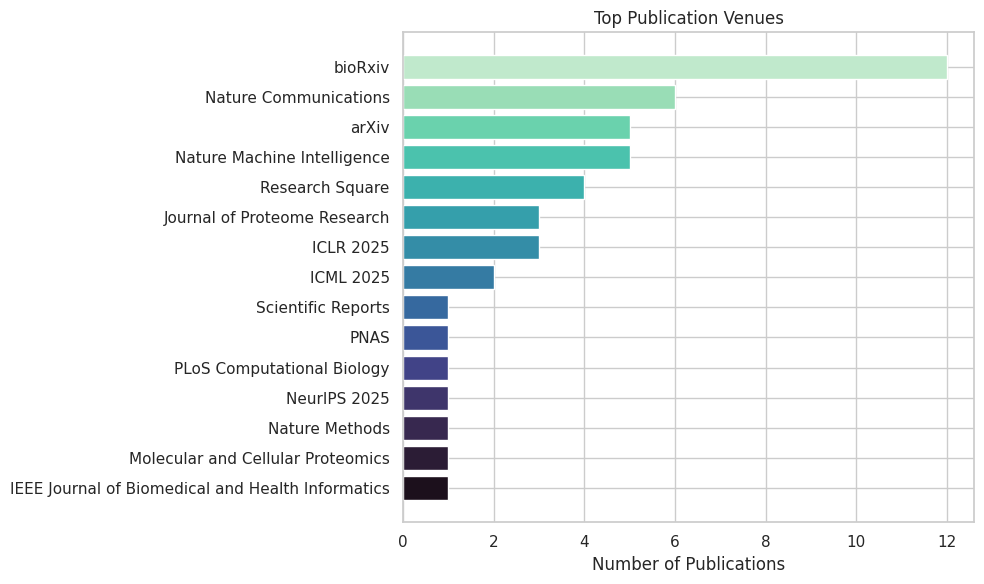

In [219]:
df_journals = pd.read_sql("""
    SELECT journal, COUNT(*) as cnt
    FROM publication
    WHERE journal IS NOT NULL
    GROUP BY journal
    ORDER BY cnt DESC
""", conn)

fig, ax = plt.subplots(figsize=(10, 6))
top_journals = df_journals.head(15)
ax.barh(top_journals["journal"][::-1], top_journals["cnt"][::-1],
        color=sns.color_palette("mako", len(top_journals)))
ax.set_xlabel("Number of Publications")
ax.set_title("Top Publication Venues")
plt.tight_layout()
plt.savefig("plots/top_venues.png", dpi=150, bbox_inches="tight")
plt.show()

## 12. Custom Queries

Use the cell below to run custom SQL queries against the database.

In [220]:
# Example: find all publications by a specific author
pd.read_sql("""
    SELECT p.title, p.publication_date, a2.name as algorithm
    FROM author a
    JOIN publication_author pa ON a.id = pa.author_id
    JOIN publication p ON pa.publication_id = p.id
    LEFT JOIN publication_algorithm pal ON p.id = pal.publication_id
    LEFT JOIN algorithm a2 ON pal.algorithm_id = a2.id
    WHERE a.name = 'Siqi Sun'
    ORDER BY p.publication_date DESC
""", conn)

,title,publication_date,algorithm
0,Accurate de novo sequencing of the modified pr...,2025-12-13,OmniNovo
1,Bidirectional Representations Augmented Autore...,2025-10-17,CrossNovo
2,MassNet: billion-scale AI-friendly mass spectr...,2025-06-26,XuanjiNovo
3,Curriculum Learning for Biological Sequence Pr...,2025-06-16,RefineNovo
4,Distilling Non-Autoregressive Model Knowledge ...,2025-02-05,XA-Novo
5,π-PrimeNovo: an accurate and efficient non-aut...,2025-01-02,π-PrimeNovo
6,RankNovo: A Universal Reranking Approach for R...,2024-11-20,RankNovo
7,ContraNovo: A Contrastive Learning Approach to...,2023-12-18,ContraNovo


In [221]:
# Example: find all affiliations for an author
pd.read_sql("""
    SELECT a.name as author, af.name as institution, af.department, c.name as country
    FROM author a
    JOIN author_affiliation aa ON a.id = aa.author_id
    JOIN affiliation af ON aa.affiliation_id = af.id
    JOIN country c ON af.country_id = c.id
    WHERE a.name = 'Xiang Zhang'
""", conn)

,author,institution,department,country
0,Xiang Zhang,University of British Columbia,Department of Computer Science,Canada
1,Xiang Zhang,Fudan University,Research Institute of Intelligent Complex Systems,China
2,Xiang Zhang,Shanghai Artificial Intelligence Laboratory,NaN,China
3,Xiang Zhang,Shandong University of Technology,School of Computer Science and Technology,China


In [222]:
conn.close()